
=== PrimeVul | Within-Project: linux | SVMSMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (linux): (43212, 768)  vuln=1002  benign=42210
      Test  (linux): (4140, 768)  vuln=70  benign=4070
      Train imbalance ratio: 0.0232

[2/6] Normalising embeddings...

[3/6] Applying SVMSMOTE...
      Before SVMSMOTE — benign: 42210 | vuln: 1002 | ratio: 42.13
      After  SVMSMOTE — benign: 42210 | vuln: 23664 | ratio: 1.78

[4/6] Computing class weights...
      Class weights (post-SVMSMOTE): {0: 0.7803127221037669, 1: 1.3918610547667343}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.5535
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.4934
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.4495
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.4181
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.3856
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.3610
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.3435
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.3303
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.3176
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.3026
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.2911
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.2826
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.2730
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.2651
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.2632
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.2529
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.5466
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.4912
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.4555
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.4272
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.4025
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.3800
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.3595
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.3449
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.3293
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.3169
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.3053
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.2962
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.2850
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.2794
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.2684
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.2649
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.5188
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.4690
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.4325
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.3927
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.3637
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.3433
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.3236
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.3100
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.2983
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.2855
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.2716
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.2624
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.2552
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.2465
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.2364
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.2307
 

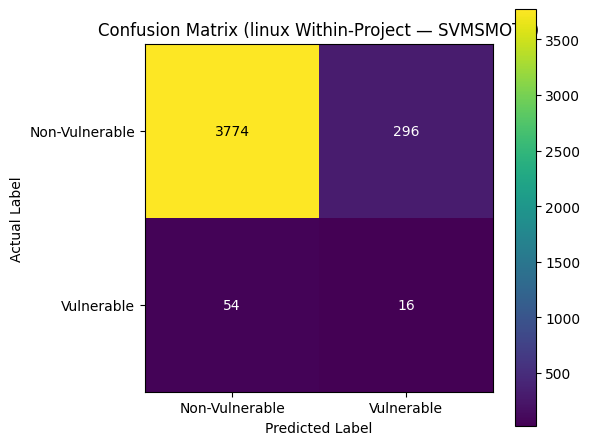

In [1]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on linux (train split) -> Test on linux (test split)
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "linux"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/svmsmote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the SVMSMOTE-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SVMSMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SVMSMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to linux only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SVMSMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SVMSMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SVMSMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    svmsmote = SVMSMOTE(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # SVMSMOTE can fail if the minority class is tiny; relax neighbors if needed
        print(f"      SVMSMOTE default failed ({e}). Retrying with k_neighbors=1, m_neighbors=3...")
        svmsmote = SVMSMOTE(random_state=SEED, k_neighbors=1, m_neighbors=3)
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SVMSMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SVMSMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "svmsmote_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_svmsmote": int(len(train_lbl)),
        "n_train_after_svmsmote" : int(len(train_lbl_res)),
        "n_vuln_before_svmsmote" : n_pos_before,
        "n_benign_before_svmsmote": n_neg_before,
        "n_vuln_after_svmsmote"   : n_pos_after,
        "n_benign_after_svmsmote" : n_neg_after,
        "n_test_samples"         : int(len(test_lbl)),
        "n_vuln_test"            : int(test_lbl.sum()),
        "class_weights"          : class_weights,
        "accuracy"               : round(float(accuracy),  4),
        "precision"              : round(float(precision), 4),
        "recall"                 : round(float(recall),    4),
        "f1"                     : round(float(f1),        4),
        "auc"                    : round(float(auc),       4),
        "g_mean"                 : round(float(g_mean),    4),
        "pf"                     : round(float(pf),        4),
        "confusion_matrix"       : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"svmsmote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_svmsmote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: tensorflow | SVMSMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (tensorflow): (1089, 768)  vuln=76  benign=1013
      Test  (tensorflow): (1313, 768)  vuln=91  benign=1222
      Train imbalance ratio: 0.0698

[2/6] Normalising embeddings...

[3/6] Applying SVMSMOTE...
      Before SVMSMOTE — benign: 1013 | vuln: 76 | ratio: 13.33
      After  SVMSMOTE — benign: 1013 | vuln: 591 | ratio: 1.71

[4/6] Computing class weights...
      Class weights (post-SVMSMOTE): {0: 0.7917077986179665, 1: 1.3570219966159052}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6783
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6768
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6755
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6741
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6726
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6712
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6697
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6681
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6662
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6642
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6616
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6588
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6556
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6520
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6484
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6441
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6796
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6782
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6769
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6757
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6744
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6734
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6724
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6713
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6699
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6684
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6667
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6648
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6627
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6606
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6582
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6554
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6816
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6808
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6799
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6790
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6777
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6761
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6743
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6723
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6700
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6672
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6637
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6597
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6552
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6500
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6440
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6374
 

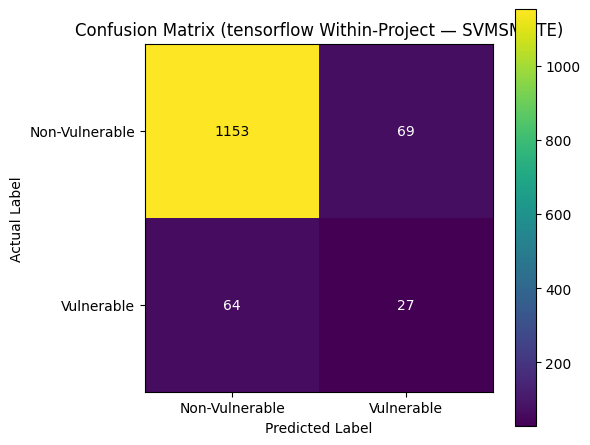

In [2]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on tensorflow (train split) -> Test on tensorflow (test split)
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "tensorflow"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/svmsmote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the SVMSMOTE-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SVMSMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SVMSMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to tensorflow only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SVMSMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SVMSMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SVMSMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    svmsmote = SVMSMOTE(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # SVMSMOTE can fail if the minority class is tiny; relax neighbors if needed
        print(f"      SVMSMOTE default failed ({e}). Retrying with k_neighbors=1, m_neighbors=3...")
        svmsmote = SVMSMOTE(random_state=SEED, k_neighbors=1, m_neighbors=3)
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SVMSMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SVMSMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "svmsmote_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_svmsmote": int(len(train_lbl)),
        "n_train_after_svmsmote" : int(len(train_lbl_res)),
        "n_vuln_before_svmsmote" : n_pos_before,
        "n_benign_before_svmsmote": n_neg_before,
        "n_vuln_after_svmsmote"   : n_pos_after,
        "n_benign_after_svmsmote" : n_neg_after,
        "n_test_samples"         : int(len(test_lbl)),
        "n_vuln_test"            : int(test_lbl.sum()),
        "class_weights"          : class_weights,
        "accuracy"               : round(float(accuracy),  4),
        "precision"              : round(float(precision), 4),
        "recall"                 : round(float(recall),    4),
        "f1"                     : round(float(f1),        4),
        "auc"                    : round(float(auc),       4),
        "g_mean"                 : round(float(g_mean),    4),
        "pf"                     : round(float(pf),        4),
        "confusion_matrix"       : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"svmsmote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_svmsmote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: vim | SVMSMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (vim): (951, 768)  vuln=38  benign=913
      Test  (vim): (1669, 768)  vuln=61  benign=1608
      Train imbalance ratio: 0.0400

[2/6] Normalising embeddings...

[3/6] Applying SVMSMOTE...
      Before SVMSMOTE — benign: 913 | vuln: 38 | ratio: 24.03
      After  SVMSMOTE — benign: 913 | vuln: 519 | ratio: 1.76

[4/6] Computing class weights...
      Class weights (post-SVMSMOTE): {0: 0.7842278203723987, 1: 1.3795761078998072}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6904
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6893
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6882
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6872
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6862
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6851
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6840
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6826
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6810
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6791
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6770
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6746
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6721
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6692
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6662
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6629
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6969
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6959
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6948
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6938
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6928
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6918
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6908
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6898
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6889
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6879
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6867
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6851
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6830
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6806
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6777
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6746
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6915
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6908
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6902
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6894
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6884
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6871
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6856
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6839
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6821
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6801
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6779
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6752
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6722
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6687
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6645
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6600
 

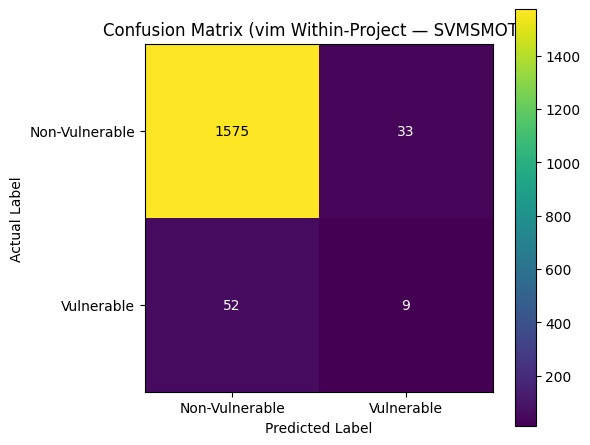

In [3]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on vim (train split) -> Test on vim (test split)
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "vim"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/svmsmote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the SVMSMOTE-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SVMSMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SVMSMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to vim only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SVMSMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SVMSMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SVMSMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    svmsmote = SVMSMOTE(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # SVMSMOTE can fail if the minority class is tiny; relax neighbors if needed
        print(f"      SVMSMOTE default failed ({e}). Retrying with k_neighbors=1, m_neighbors=3...")
        svmsmote = SVMSMOTE(random_state=SEED, k_neighbors=1, m_neighbors=3)
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SVMSMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SVMSMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "svmsmote_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_svmsmote": int(len(train_lbl)),
        "n_train_after_svmsmote" : int(len(train_lbl_res)),
        "n_vuln_before_svmsmote" : n_pos_before,
        "n_benign_before_svmsmote": n_neg_before,
        "n_vuln_after_svmsmote"   : n_pos_after,
        "n_benign_after_svmsmote" : n_neg_after,
        "n_test_samples"         : int(len(test_lbl)),
        "n_vuln_test"            : int(test_lbl.sum()),
        "class_weights"          : class_weights,
        "accuracy"               : round(float(accuracy),  4),
        "precision"              : round(float(precision), 4),
        "recall"                 : round(float(recall),    4),
        "f1"                     : round(float(f1),        4),
        "auc"                    : round(float(auc),       4),
        "g_mean"                 : round(float(g_mean),    4),
        "pf"                     : round(float(pf),        4),
        "confusion_matrix"       : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"svmsmote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_svmsmote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: gpac | SVMSMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (gpac): (2775, 768)  vuln=32  benign=2743
      Test  (gpac): (1884, 768)  vuln=18  benign=1866
      Train imbalance ratio: 0.0115

[2/6] Normalising embeddings...

[3/6] Applying SVMSMOTE...
      Before SVMSMOTE — benign: 2743 | vuln: 32 | ratio: 85.72
      After  SVMSMOTE — benign: 2743 | vuln: 1523 | ratio: 1.80

[4/6] Computing class weights...
      Class weights (post-SVMSMOTE): {0: 0.7776157491797302, 1: 1.4005252790544978}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6731
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6685
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6630
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6560
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6469
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6346
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6194
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6010
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.5791
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.5545
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.5296
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.5047
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.4819
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.4604
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.4409
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.4239
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6735
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6699
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6667
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6612
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6536
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6446
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6315
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6139
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.5916
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.5664
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.5391
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.5105
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.4833
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.4562
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.4329
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.4136
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6779
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6740
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6687
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6605
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6472
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6261
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.5970
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.5636
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.5271
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.4926
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.4630
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.4390
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.4201
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.4042
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.3848
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.3619
 

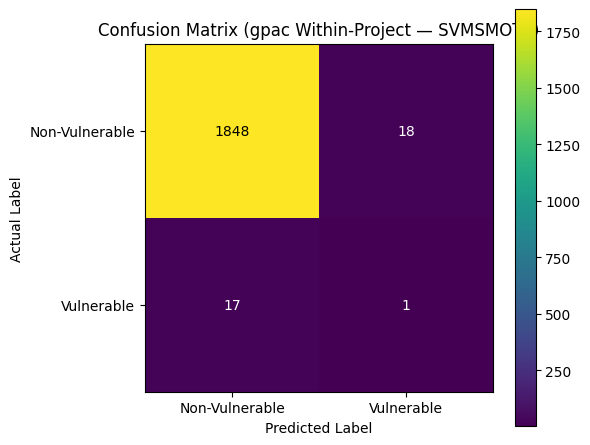

In [4]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on gpac (train split) -> Test on gpac (test split)
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "gpac"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/svmsmote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the SVMSMOTE-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SVMSMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SVMSMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to gpac only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SVMSMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SVMSMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SVMSMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    svmsmote = SVMSMOTE(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # SVMSMOTE can fail if the minority class is tiny; relax neighbors if needed
        print(f"      SVMSMOTE default failed ({e}). Retrying with k_neighbors=1, m_neighbors=3...")
        svmsmote = SVMSMOTE(random_state=SEED, k_neighbors=1, m_neighbors=3)
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SVMSMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SVMSMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "svmsmote_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_svmsmote": int(len(train_lbl)),
        "n_train_after_svmsmote" : int(len(train_lbl_res)),
        "n_vuln_before_svmsmote" : n_pos_before,
        "n_benign_before_svmsmote": n_neg_before,
        "n_vuln_after_svmsmote"   : n_pos_after,
        "n_benign_after_svmsmote" : n_neg_after,
        "n_test_samples"         : int(len(test_lbl)),
        "n_vuln_test"            : int(test_lbl.sum()),
        "class_weights"          : class_weights,
        "accuracy"               : round(float(accuracy),  4),
        "precision"              : round(float(precision), 4),
        "recall"                 : round(float(recall),    4),
        "f1"                     : round(float(f1),        4),
        "auc"                    : round(float(auc),       4),
        "g_mean"                 : round(float(g_mean),    4),
        "pf"                     : round(float(pf),        4),
        "confusion_matrix"       : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"svmsmote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_svmsmote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()


=== PrimeVul | Within-Project: FreeRDP | SVMSMOTE ===
    Device: mps

[1/6] Loading embeddings...
      Train (FreeRDP): (872, 768)  vuln=23  benign=849
      Test  (FreeRDP): (26, 768)  vuln=1  benign=25
      Train imbalance ratio: 0.0264

[2/6] Normalising embeddings...

[3/6] Applying SVMSMOTE...
      Before SVMSMOTE — benign: 849 | vuln: 23 | ratio: 36.91
      After  SVMSMOTE — benign: 849 | vuln: 477 | ratio: 1.78

[4/6] Computing class weights...
      Class weights (post-SVMSMOTE): {0: 0.7809187279151943, 1: 1.389937106918239}

[5/6] Running ensemble iterations...


Ensemble:   0%|          | 0/3 [00:00<?, ?iter/s]


      [Iteration 1/3] Training neural network...


Iter 1 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 1 - Within-Project | Epoch 1/50 - val_loss: 0.6884
      Iter 1 - Within-Project | Epoch 2/50 - val_loss: 0.6870
      Iter 1 - Within-Project | Epoch 3/50 - val_loss: 0.6859
      Iter 1 - Within-Project | Epoch 4/50 - val_loss: 0.6848
      Iter 1 - Within-Project | Epoch 5/50 - val_loss: 0.6838
      Iter 1 - Within-Project | Epoch 6/50 - val_loss: 0.6826
      Iter 1 - Within-Project | Epoch 7/50 - val_loss: 0.6813
      Iter 1 - Within-Project | Epoch 8/50 - val_loss: 0.6798
      Iter 1 - Within-Project | Epoch 9/50 - val_loss: 0.6782
      Iter 1 - Within-Project | Epoch 10/50 - val_loss: 0.6764
      Iter 1 - Within-Project | Epoch 11/50 - val_loss: 0.6746
      Iter 1 - Within-Project | Epoch 12/50 - val_loss: 0.6725
      Iter 1 - Within-Project | Epoch 13/50 - val_loss: 0.6702
      Iter 1 - Within-Project | Epoch 14/50 - val_loss: 0.6678
      Iter 1 - Within-Project | Epoch 15/50 - val_loss: 0.6649
      Iter 1 - Within-Project | Epoch 16/50 - val_loss: 0.6619
 

Iter 2 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 2 - Within-Project | Epoch 1/50 - val_loss: 0.6941
      Iter 2 - Within-Project | Epoch 2/50 - val_loss: 0.6928
      Iter 2 - Within-Project | Epoch 3/50 - val_loss: 0.6916
      Iter 2 - Within-Project | Epoch 4/50 - val_loss: 0.6904
      Iter 2 - Within-Project | Epoch 5/50 - val_loss: 0.6892
      Iter 2 - Within-Project | Epoch 6/50 - val_loss: 0.6877
      Iter 2 - Within-Project | Epoch 7/50 - val_loss: 0.6864
      Iter 2 - Within-Project | Epoch 8/50 - val_loss: 0.6852
      Iter 2 - Within-Project | Epoch 9/50 - val_loss: 0.6840
      Iter 2 - Within-Project | Epoch 10/50 - val_loss: 0.6826
      Iter 2 - Within-Project | Epoch 11/50 - val_loss: 0.6812
      Iter 2 - Within-Project | Epoch 12/50 - val_loss: 0.6796
      Iter 2 - Within-Project | Epoch 13/50 - val_loss: 0.6779
      Iter 2 - Within-Project | Epoch 14/50 - val_loss: 0.6760
      Iter 2 - Within-Project | Epoch 15/50 - val_loss: 0.6737
      Iter 2 - Within-Project | Epoch 16/50 - val_loss: 0.6712
 

Iter 3 - Within-Project:   0%|          | 0/50 [00:00<?, ?it/s]

      Iter 3 - Within-Project | Epoch 1/50 - val_loss: 0.6905
      Iter 3 - Within-Project | Epoch 2/50 - val_loss: 0.6897
      Iter 3 - Within-Project | Epoch 3/50 - val_loss: 0.6890
      Iter 3 - Within-Project | Epoch 4/50 - val_loss: 0.6881
      Iter 3 - Within-Project | Epoch 5/50 - val_loss: 0.6870
      Iter 3 - Within-Project | Epoch 6/50 - val_loss: 0.6857
      Iter 3 - Within-Project | Epoch 7/50 - val_loss: 0.6841
      Iter 3 - Within-Project | Epoch 8/50 - val_loss: 0.6825
      Iter 3 - Within-Project | Epoch 9/50 - val_loss: 0.6807
      Iter 3 - Within-Project | Epoch 10/50 - val_loss: 0.6787
      Iter 3 - Within-Project | Epoch 11/50 - val_loss: 0.6764
      Iter 3 - Within-Project | Epoch 12/50 - val_loss: 0.6739
      Iter 3 - Within-Project | Epoch 13/50 - val_loss: 0.6710
      Iter 3 - Within-Project | Epoch 14/50 - val_loss: 0.6676
      Iter 3 - Within-Project | Epoch 15/50 - val_loss: 0.6636
      Iter 3 - Within-Project | Epoch 16/50 - val_loss: 0.6592
 

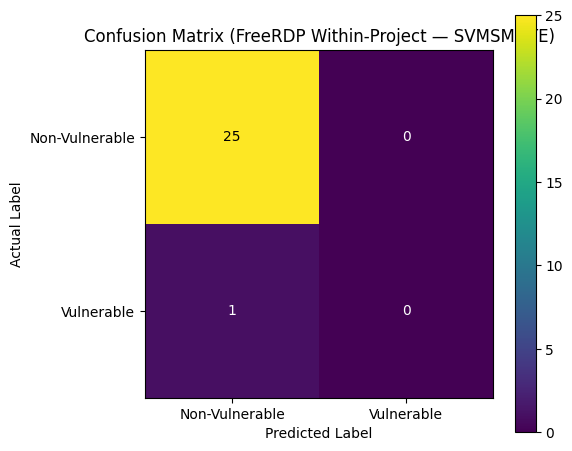

In [5]:
"""
Within-Project Vulnerability Detection on PrimeVul
---------------------------------------------------
Train on FreeRDP (train split) -> Test on FreeRDP (test split)
SVMSMOTE Oversampling
"""

import os
import json
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, recall_score, precision_score,
    roc_auc_score, f1_score, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SVMSMOTE
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

# =========================================================
# Config
# =========================================================
SEED       = 42
PROJECT    = "FreeRDP"
TRAIN_FILE = "../../../../embedding/primevul/codebert/p_train_embedded.jsonl"
TEST_FILE  = "../../../../embedding/primevul/codebert/p_test_embedded.jsonl"
EMB_KEY    = "emb"
OUTPUT_DIR = "results/svmsmote"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = "mps"
    torch.mps.manual_seed(SEED)
elif torch.cuda.is_available():
    DEVICE = "cuda"
    torch.cuda.manual_seed_all(SEED)
else:
    DEVICE = "cpu"


# =========================================================
# Data Loading
# =========================================================
def load_jsonl(path):
    """Load a PrimeVul embedded JSONL file.
    Returns X (embeddings), y (labels), projects (project names).
    """
    records = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    X        = np.array([r[EMB_KEY]   for r in records], dtype=np.float32)
    y        = np.array([r["target"]  for r in records], dtype=np.int32)
    projects = np.array([r["project"] for r in records], dtype=object)
    return X, y, projects


# =========================================================
# Neural Network
# =========================================================
class VulnerabilityClassifier(nn.Module):
    def __init__(self, input_dim):
        super(VulnerabilityClassifier, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)


# =========================================================
# Training Loop
# =========================================================
def train_neural_network(model, dataloader, x_val, y_val,
                         optimizer, class_weights, epochs, desc):
    pos_weight = torch.tensor(class_weights[1], dtype=torch.float32).to(DEVICE)
    neg_weight = torch.tensor(class_weights[0], dtype=torch.float32).to(DEVICE)
    criterion  = nn.BCELoss(reduction='none')

    for epoch in tqdm(range(epochs), desc=desc, leave=False):
        model.train()
        for x_batch, y_batch in dataloader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            optimizer.zero_grad()
            predictions = model(x_batch).squeeze(-1)
            weights     = torch.where(y_batch == 1, pos_weight, neg_weight)
            loss        = (criterion(predictions, y_batch) * weights).mean()
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_preds = model(x_val).squeeze(-1)
            weights   = torch.where(y_val == 1, pos_weight, neg_weight)
            val_loss  = (criterion(val_preds, y_val) * weights).mean().item()
        print(f"      {desc} | Epoch {epoch+1}/{epochs} - val_loss: {val_loss:.4f}")

    return model


# =========================================================
# Within-Project Training (no pseudo-labelling)
# =========================================================
def train_within_project(x_train, y_train, class_weights, iteration):
    """
    Single-phase training on the SVMSMOTE-augmented within-project
    train split. No pseudo-labelling since train and test come
    from the same project — there is no domain gap to bridge.
    """
    x_tr, x_val, y_tr, y_val = train_test_split(
        x_train, y_train,
        test_size=0.2,
        random_state=SEED
    )

    x_tr_t  = torch.tensor(x_tr,  dtype=torch.float32)
    y_tr_t  = torch.tensor(y_tr,  dtype=torch.float32)
    x_val_t = torch.tensor(x_val, dtype=torch.float32).to(DEVICE)
    y_val_t = torch.tensor(y_val, dtype=torch.float32).to(DEVICE)

    dataset    = TensorDataset(x_tr_t, y_tr_t)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

    model     = VulnerabilityClassifier(x_train.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

    model = train_neural_network(
        model, dataloader, x_val_t, y_val_t,
        optimizer, class_weights,
        epochs=50,
        desc=f"Iter {iteration} - Within-Project"
    )

    return model


# =========================================================
# XGBoost
# =========================================================
def train_base_model_xgb(x_train, y_train, class_weights,
                         sample_weights=None):
    scale_pos_weight = class_weights[1] / class_weights[0]
    model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight,
        random_state=SEED
    )
    model.fit(x_train, y_train, sample_weight=sample_weights)
    return model


# =========================================================
# Confusion Matrix Plot
# =========================================================
def plot_confusion_matrix(tn, fp, fn, tp, save_path):
    cm = np.array([[tn, fp],
                   [fn, tp]])

    fig, ax = plt.subplots(figsize=(6, 5))
    img = ax.imshow(cm, interpolation='nearest')
    ax.set_title(f"Confusion Matrix ({PROJECT} Within-Project — SVMSMOTE)")
    plt.colorbar(img, ax=ax)

    tick_marks = np.arange(2)
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(["Non-Vulnerable", "Vulnerable"])
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(["Non-Vulnerable", "Vulnerable"])

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            color = "black" if cm[i, j] > thresh else "white"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)

    ax.set_ylabel("Actual Label")
    ax.set_xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    print(f"Confusion matrix saved as {save_path}")
    plt.show()


# =========================================================
# Main
# =========================================================
def main():
    print(f"\n=== PrimeVul | Within-Project: {PROJECT} | SVMSMOTE ===")
    print(f"    Device: {DEVICE}")

    # ----------------------------------------------------------
    # [1/6] Load embeddings
    # ----------------------------------------------------------
    print("\n[1/6] Loading embeddings...")

    X_tr, y_tr, proj_tr = load_jsonl(TRAIN_FILE)
    X_te, y_te, proj_te = load_jsonl(TEST_FILE)

    # Filter both splits to FreeRDP only
    train_mask = proj_tr == PROJECT
    test_mask  = proj_te == PROJECT

    train_emb = X_tr[train_mask].astype(np.float32)
    train_lbl = y_tr[train_mask].astype(np.int32)
    test_emb  = X_te[test_mask].astype(np.float32)
    test_lbl  = y_te[test_mask].astype(np.int32)

    if train_emb.shape[0] == 0:
        raise ValueError(f"No training samples found for '{PROJECT}' in {TRAIN_FILE}.")
    if test_emb.shape[0] == 0:
        raise ValueError(f"No test samples found for '{PROJECT}' in {TEST_FILE}.")

    print(f"      Train ({PROJECT}): {train_emb.shape}  "
          f"vuln={train_lbl.sum()}  benign={int((train_lbl == 0).sum())}")
    print(f"      Test  ({PROJECT}): {test_emb.shape}  "
          f"vuln={test_lbl.sum()}  benign={int((test_lbl == 0).sum())}")
    print(f"      Train imbalance ratio: {train_lbl.sum() / len(train_lbl):.4f}")

    # ----------------------------------------------------------
    # [2/6] Normalise embeddings
    # ----------------------------------------------------------
    print("\n[2/6] Normalising embeddings...")
    scaler    = StandardScaler()
    train_emb = scaler.fit_transform(train_emb).astype(np.float32)
    test_emb  = scaler.transform(test_emb).astype(np.float32)

    # ----------------------------------------------------------
    # [3/6] Apply SVMSMOTE on training split only
    # ----------------------------------------------------------
    print("\n[3/6] Applying SVMSMOTE...")
    n_neg_before = int(np.sum(train_lbl == 0))
    n_pos_before = int(np.sum(train_lbl == 1))
    print(f"      Before SVMSMOTE — benign: {n_neg_before} | vuln: {n_pos_before} "
          f"| ratio: {n_neg_before / n_pos_before:.2f}")

    svmsmote = SVMSMOTE(random_state=SEED)
    try:
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)
    except ValueError as e:
        # SVMSMOTE can fail if the minority class is tiny; relax neighbors if needed
        print(f"      SVMSMOTE default failed ({e}). Retrying with k_neighbors=1, m_neighbors=3...")
        svmsmote = SVMSMOTE(random_state=SEED, k_neighbors=1, m_neighbors=3)
        train_emb_res, train_lbl_res = svmsmote.fit_resample(train_emb, train_lbl)

    train_emb_res = train_emb_res.astype(np.float32)
    train_lbl_res = train_lbl_res.astype(np.int32)

    n_neg_after = int(np.sum(train_lbl_res == 0))
    n_pos_after = int(np.sum(train_lbl_res == 1))
    print(f"      After  SVMSMOTE — benign: {n_neg_after} | vuln: {n_pos_after} "
          f"| ratio: {n_neg_after / n_pos_after:.2f}")

    # ----------------------------------------------------------
    # [4/6] Compute class weights from RESAMPLED train split
    # ----------------------------------------------------------
    print("\n[4/6] Computing class weights...")
    classes           = np.unique(train_lbl_res)
    class_weights_arr = compute_class_weight(
                            class_weight='balanced',
                            classes=classes,
                            y=train_lbl_res
                        )
    class_weights     = {int(cls): float(w)
                         for cls, w in zip(classes, class_weights_arr)}
    print(f"      Class weights (post-SVMSMOTE): {class_weights}")

    # ----------------------------------------------------------
    # [5/6] Ensemble (NN + XGBoost) x 3 iterations
    # ----------------------------------------------------------
    print("\n[5/6] Running ensemble iterations...")
    num_iterations       = 3
    ensemble_predictions = np.zeros(len(test_lbl))

    for i in tqdm(range(num_iterations), desc="Ensemble", unit="iter"):
        print(f"\n      [Iteration {i+1}/{num_iterations}] Training neural network...")
        model_nn = train_within_project(
            train_emb_res, train_lbl_res,
            class_weights,
            iteration=i+1
        )

        print(f"      [Iteration {i+1}/{num_iterations}] Training XGBoost...")
        model_nn.eval()
        with torch.no_grad():
            x_tr_t       = torch.tensor(train_emb_res, dtype=torch.float32).to(DEVICE)
            y_train_pred = model_nn(x_tr_t).squeeze(-1).cpu().numpy()

        sample_weights        = np.where(
                                    train_lbl_res == 1,
                                    y_train_pred,
                                    1 - y_train_pred
                                )
        model_xgb             = train_base_model_xgb(
                                    train_emb_res, train_lbl_res,
                                    class_weights,
                                    sample_weights
                                )
        model_xgb_pred        = model_xgb.predict_proba(test_emb)[:, 1]
        ensemble_predictions += model_xgb_pred
        print(f"      [Iteration {i+1}/{num_iterations}] Done")

    # ----------------------------------------------------------
    # [6/6] Metrics
    # ----------------------------------------------------------
    print("\n[6/6] Computing metrics...")
    ensemble_avg = ensemble_predictions / num_iterations
    y_pred_final = (ensemble_avg > 0.5).astype(int)

    accuracy  = accuracy_score(test_lbl,  y_pred_final)
    recall    = recall_score(test_lbl,    y_pred_final, zero_division=0)
    precision = precision_score(test_lbl, y_pred_final, zero_division=0)
    auc       = roc_auc_score(test_lbl,   ensemble_avg)
    f1        = f1_score(test_lbl,        y_pred_final, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(test_lbl, y_pred_final).ravel()
    g_mean = np.sqrt((tp / (tp + fn + 1e-9)) * (tn / (tn + fp + 1e-9)))
    pf     = fp / (fp + tn + 1e-9)

    print(f"\n=== Evaluation Results ({PROJECT} Within-Project Test Set) ===")
    print(f"Accuracy  : {accuracy:.3f}")
    print(f"Precision : {precision:.3f}")
    print(f"Recall    : {recall:.3f}")
    print(f"F1-score  : {f1:.3f}")
    print(f"AUC       : {auc:.3f}")
    print(f"G-mean    : {g_mean:.3f}")
    print(f"PF value  : {pf:.3f}")
    print("\nConfusion Matrix:")
    print(f"  TN: {tn}  FP: {fp}")
    print(f"  FN: {fn}  TP: {tp}")

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    results = {
        "experiment"            : "svmsmote_within_project",
        "setting"               : "within_project",
        "project"               : PROJECT,
        "n_train_before_svmsmote": int(len(train_lbl)),
        "n_train_after_svmsmote" : int(len(train_lbl_res)),
        "n_vuln_before_svmsmote" : n_pos_before,
        "n_benign_before_svmsmote": n_neg_before,
        "n_vuln_after_svmsmote"   : n_pos_after,
        "n_benign_after_svmsmote" : n_neg_after,
        "n_test_samples"         : int(len(test_lbl)),
        "n_vuln_test"            : int(test_lbl.sum()),
        "class_weights"          : class_weights,
        "accuracy"               : round(float(accuracy),  4),
        "precision"              : round(float(precision), 4),
        "recall"                 : round(float(recall),    4),
        "f1"                     : round(float(f1),        4),
        "auc"                    : round(float(auc),       4),
        "g_mean"                 : round(float(g_mean),    4),
        "pf"                     : round(float(pf),        4),
        "confusion_matrix"       : {
            "tn": int(tn), "fp": int(fp),
            "fn": int(fn), "tp": int(tp)
        }
    }

    json_path = os.path.join(OUTPUT_DIR, f"svmsmote_within_{PROJECT}.json")
    with open(json_path, "w") as f:
        json.dump(results, f, indent=2)
    print(f"\nResults saved to {json_path}")

    cm_path = os.path.join(OUTPUT_DIR, f"confusion_matrix_svmsmote_within_{PROJECT}.png")
    plot_confusion_matrix(tn, fp, fn, tp, cm_path)


if __name__ == "__main__":
    main()